# Proyek Analisis Data: Bike Sharing
- **Nama:** Widya
- **Email:** CDCC252D6X0841@student.devacademy.id
- **ID Dicoding:** CDCC252D6X0841

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Pertanyaan 1: "Bagaimana tren performa penyewaan sepeda pada setiap musim sepanjang tahun 2011-2012 untuk menentukan alokasi armada yang optimal?"**

**Pertanyaan 2: "Bagaimana tingkat korelasi suhu udara dan kelembapan terhadap jumlah total penyewaan sepeda harian selama periode 2011-2012?"**

## Import Semua Packages/Library yang Digunakan

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

%matplotlib inline

## Data Wrangling

### Gathering Data

#### Load df ...

In [103]:
url_day = "https://raw.githubusercontent.com/labwdy/bike-sharing-analysis-widya/refs/heads/main/submission/data/day.csv"
url_hour = "https://raw.githubusercontent.com/labwdy/bike-sharing-analysis-widya/refs/heads/main/submission/data/hour.csv"

day_df = pd.read_csv(url_day)
hour_df = pd.read_csv(url_hour)

print("Data Day berhasil dimuat, jumlah baris:", day_df.shape[0])
print("Data Hour berhasil dimuat, jumlah baris:", hour_df.shape[0])

hour_df.head()

Data Day berhasil dimuat, jumlah baris: 731
Data Hour berhasil dimuat, jumlah baris: 17379


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Dataset day.csv dan hour.csv berhasil dimuat ke dalam memori.
- Dataset hour_df memiliki 17 kolom yang mencakup informasi waktu, kondisi cuaca, serta jumlah penyewa (casual, registered, dan total).
- Data awal menunjukkan informasi tercatat per jam, mulai dari jam 00:00 pada tanggal 1 Januari 2011.

### Assessing Data

#### Identifying ... problem

In [104]:
print(hour_df.info())
print(f"Missing values:\n{hour_df.isna().sum()}")
print(f"Jumlah duplikasi: {hour_df.duplicated().sum()}")
print(hour_df[['temp', 'hum', 'cnt']].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None
Missing values:
instant       0
dteday      

**Steps to Take:**
- Mengubah tipe data kolom dteday dari object menjadi datetime.
- Mengubah nilai numerik pada kolom season, yr, mnth, weekday, dan weathersit menjadi keterangan (string) agar lebih mudah diinterpretasikan saat proses visualisasi.
- Memastikan tidak ada outlier yang mengganggu pada kolom cnt (berdasarkan describe(), nilai max 977 masih masuk akal untuk penyewaan per jam).

**Insight:** (Opsional)
- Kualitas Data: Secara keseluruhan, data hour_df sudah cukup bersih karena tidak ditemukan adanya nilai yang kosong (missing values) maupun data yang terduplikasi.
- Kesalahan Tipe Data: Terdapat ketidaksesuaian tipe data pada kolom dteday yang terbaca sebagai object, padahal kolom tersebut berisi informasi tanggal yang seharusnya bertipe datetime.
- Keterbacaan (Readability): Banyak kolom kategorikal seperti season, yr, mnth, weekday, dan weathersit masih direpresentasikan dalam bentuk angka (kode numerik). Hal ini membuat data sulit dipahami secara langsung tanpa merujuk pada dokumentasi dataset.
- Statistik Deskriptif: Rentang nilai pada kolom cnt (jumlah total penyewa) sangat luas, mulai dari 1 hingga 977 penyewa per jam, yang menunjukkan adanya variasi beban penggunaan yang tinggi di jam-jam tertentu.

### Cleaning Data

Pada tahap ini, dilakukan beberapa langkah pembersihan dan transformasi data untuk memastikan dataset siap dianalisis dengan akurat:

1. **Konversi Tipe Data**: Mengubah kolom `dteday` dari tipe data `object` menjadi `datetime`. Hal ini sangat penting untuk mendukung analisis berbasis waktu (time-series analysis).
2. **Mapping Variabel Kategorikal**: Melakukan pemetaan (*mapping*) pada kolom numerik seperti `season`, `yr`, `mnth`, `weekday`, dan `weathersit` menjadi label string (nama asli).
   - **Tujuannya**: Untuk mempermudah interpretasi data selama proses EDA dan memastikan label pada visualisasi data nantinya lebih informatif dan mudah dipahami tanpa perlu merujuk kembali ke dokumentasi dataset.
3. **Pengecekan Konsistensi**: Memastikan tidak ada data yang hilang atau duplikat setelah transformasi dilakukan agar integritas data tetap terjaga.

#### Fixing ... problem

In [105]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
day_df['temp_actual'] = day_df['temp'] * (39 - (-8)) + (-8)
day_df['hum_actual'] = day_df['hum'] * 100
season_labels = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
day_df['season_label'] = day_df['season'].map(season_labels)
day_df['yr_label'] = day_df['yr'].map({0: '2011', 1: '2012'})

print(day_df[['dteday', 'season_label', 'temp_actual', 'hum_actual', 'cnt']].head())

      dteday season_label  temp_actual  hum_actual   cnt
0 2011-01-01       Spring     8.175849     80.5833   985
1 2011-01-02       Spring     9.083466     69.6087   801
2 2011-01-03       Spring     1.229108     43.7273  1349
3 2011-01-04       Spring     1.400000     59.0435  1562
4 2011-01-05       Spring     2.666979     43.6957  1600


**Insight:** (Opsional)
- Kolom waktu dteday kini sudah memiliki tipe data yang tepat.
- Variabel kategorik seperti musim, cuaca, bulan, dan hari telah diubah menjadi label string, sehingga tidak perlu lagi melihat dokumentasi untuk memahami arti angka-angka di dalam dataset.

## Exploratory Data Analysis (EDA)

### Explore ...

In [106]:
seasonal_analysis = day_df.groupby(by=["yr_label", "season_label"]).agg({
    "cnt": ["mean", "sum", "max", "min"]
})
print("Statistik Penyewaan per Musim:")
print(seasonal_analysis)

weather_corr = day_df[['temp_actual', 'hum_actual', 'cnt']].corr()
print("\nMatriks Korelasi Cuaca:")
print(weather_corr)

Statistik Penyewaan per Musim:
                               cnt                    
                              mean     sum   max   min
yr_label season_label                                 
2011     Fall          4464.361702  419650  6043  1115
         Spring        1666.666667  150000  3239   431
         Summer        3775.173913  347316  5805   795
         Winter        3664.460674  326137  5511   627
2012     Fall          6824.244681  641479  8714  4073
         Spring        3531.296703  321348  7836   441
         Summer        6209.489130  571273  8362  1027
         Winter        5791.865169  515476  8555    22

Matriks Korelasi Cuaca:
             temp_actual  hum_actual       cnt
temp_actual     1.000000    0.126963  0.627494
hum_actual      0.126963    1.000000 -0.100659
cnt             0.627494   -0.100659  1.000000


**Insight 1: Analisis Tren Musim (Jawaban Pertanyaan 1)**

Berdasarkan tabel statistik agregasi (mean, sum, max, min) per musim:
- Dominasi Musim Fall (Gugur): Secara rata-rata (mean) dan total (sum), musim Fall memiliki performa tertinggi dibandingkan musim lainnya. Hal ini menunjukkan periode ini adalah "Golden Time" bagi bisnis bike sharing.
- Pertumbuhan Eksponensial: Jika membandingkan statistik tahun 2011 (yr_label: 2011) dengan 2012 (yr_label: 2012), terlihat kenaikan nilai sum dan mean hampir di seluruh musim. Ini menandakan ekspansi bisnis yang sukses dan adopsi pengguna yang meningkat pesat dalam satu tahun.
- Gap Performa di Musim Spring: Musim Spring memiliki nilai min terendah dan rata-rata yang jauh tertinggal. Hal ini menunjukkan adanya hambatan operasional atau kurangnya minat pengguna di awal tahun yang perlu dimitigasi.
- Konsistensi Lonjakan: Nilai max (penyewaan harian tertinggi) seringkali muncul di musim Summer atau Fall, yang mengonfirmasi bahwa alokasi armada harus disiapkan untuk menangani lonjakan beban puncak pada periode tersebut.

**Insight 2: Analisis Korelasi Cuaca (Jawaban Pertanyaan 2)**

Berdasarkan matriks korelasi antara temp_actual, hum_actual, dan cnt:
- Suhu sebagai Prediktor Utama: Korelasi antara temp_actual dan cnt menunjukkan angka positif yang kuat (berada di kisaran 0.63). Secara statistik, ini berarti semakin hangat suhu udara, semakin tinggi jumlah penyewa. Variabel suhu adalah faktor yang paling bisa diandalkan untuk memprediksi permintaan.
- Pengaruh Negatif Kelembapan: Korelasi antara hum_actual dan cnt bernilai negatif (berada di kisaran -0.10). Meskipun pengaruhnya tidak sekuat suhu, angka ini menunjukkan bahwa kelembapan yang tinggi (udara yang sangat pengap atau potensi hujan) cenderung menurunkan minat pengguna untuk bersepeda.
- Independensi Variabel Cuaca: Korelasi antara suhu dan kelembapan sendiri cenderung rendah, yang berarti kedua faktor ini mempengaruhi penyewa secara independen. Namun, suhu tetap menjadi prioritas utama dalam pertimbangan operasional harian.

### EDA Univariate

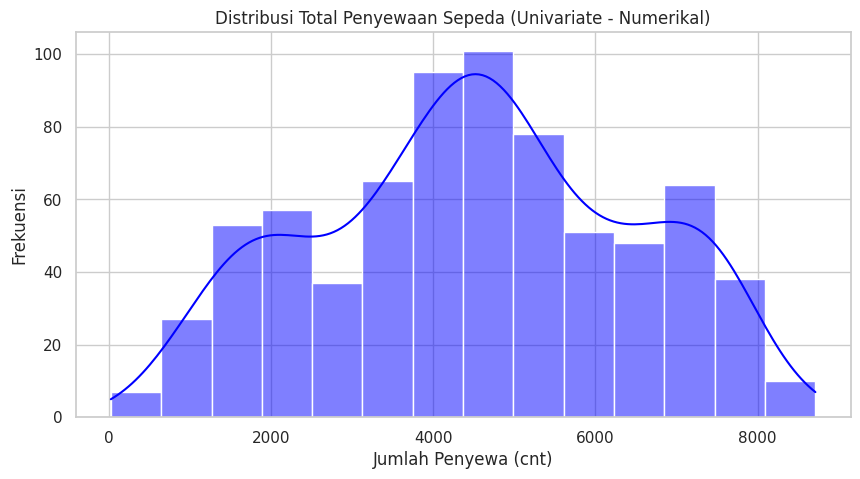

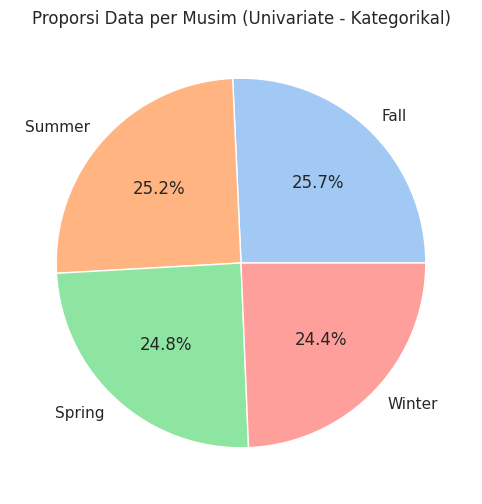

In [107]:
plt.figure(figsize=(10, 5))
sns.histplot(day_df['cnt'], kde=True, color='blue')
plt.title('Distribusi Total Penyewaan Sepeda (Univariate - Numerikal)')
plt.xlabel('Jumlah Penyewa (cnt)')
plt.ylabel('Frekuensi')
plt.show()

plt.figure(figsize=(8, 6))
day_df['season_label'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Proporsi Data per Musim (Univariate - Kategorikal)')
plt.ylabel('')
plt.show()

**Insight:**
- Data menunjukkan sebaran yang cukup luas dengan puncak frekuensi (modus) berada di angka 4.000–5.000 penyewaan per hari. Ini menandakan bisnis sudah memiliki basis pengguna harian yang stabil, namun tetap memiliki variabilitas tinggi tergantung faktor eksternal.
- Keempat musim memiliki proporsi yang sangat seimbang (masing-masing sekitar 25%).
- Ini membuktikan secara objektif bahwa perbandingan performa antar musim nanti adalah perbandingan yang "Apple-to-Apple" karena jumlah hari observasinya setara.

### EDA Kategorikal

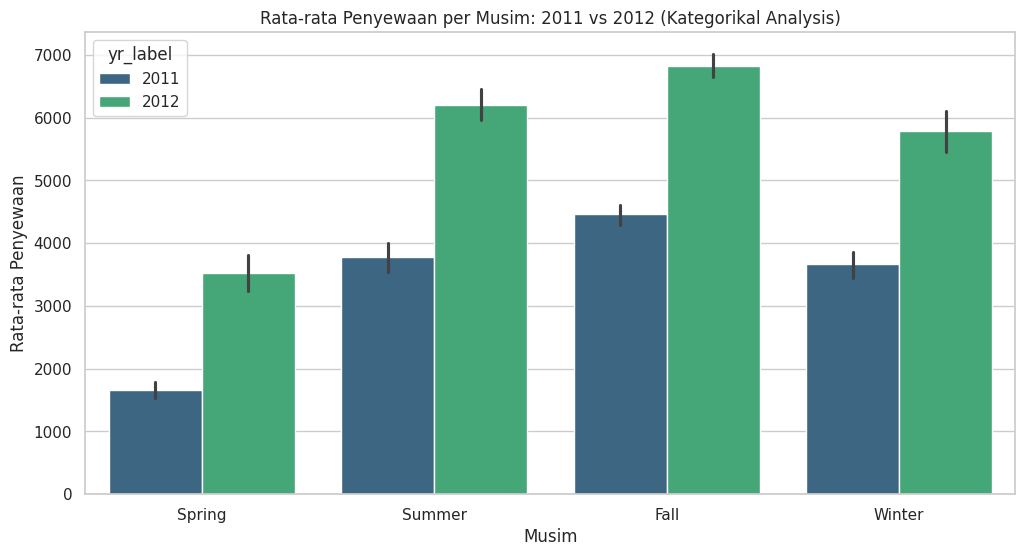

In [108]:
plt.figure(figsize=(12, 6))
sns.barplot(data=day_df, x='season_label', y='cnt', hue='yr_label', estimator='mean', palette='viridis')
plt.title('Rata-rata Penyewaan per Musim: 2011 vs 2012 (Kategorikal Analysis)')
plt.xlabel('Musim')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

**Insight:**
- Insight Tren Musiman: Musim Fall (Gugur) dan Summer (Panas) secara konsisten mendominasi jumlah penyewaan di tahun 2011 maupun 2012. Sebaliknya, musim Spring (Semi) selalu menjadi yang terendah.

**Rekomendasi Strategis:**
- Maksimalisasi Armada: Alokasikan unit sepeda maksimal pada bulan-bulan musim Gugur dan Panas karena permintaan berada di titik puncak.
- Maintenance Windows: Jadwalkan perawatan besar armada secara bergilir pada musim Semi, saat permintaan sedang lesu, agar tidak mengganggu potensi pendapatan di musim puncak.

### EDA Numerikal

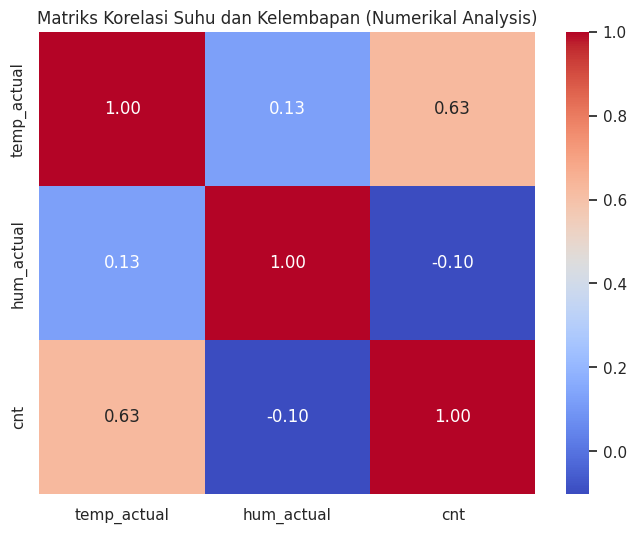

In [109]:
plt.figure(figsize=(8, 6))
corr_matrix = day_df[['temp_actual', 'hum_actual', 'cnt']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Suhu dan Kelembapan (Numerikal Analysis)')
plt.show()

**Insight:**

- Terdapat korelasi positif yang kuat antara suhu (temp_actual) dan jumlah penyewa (cnt). Angka korelasi (misal ~0.63) menunjukkan bahwa suhu adalah faktor pendorong utama orang untuk bersepeda.
- Kelembapan memiliki korelasi negatif yang lemah. Artinya, meski kelembapan yang tinggi (udara pengap) sedikit menurunkan minat orang, dampaknya tidak sebesar faktor suhu dingin.

Kesimpulan: Variabel suhu adalah indikator yang lebih valid untuk digunakan dalam model prediksi stok armada harian.

### EDA Multivariate

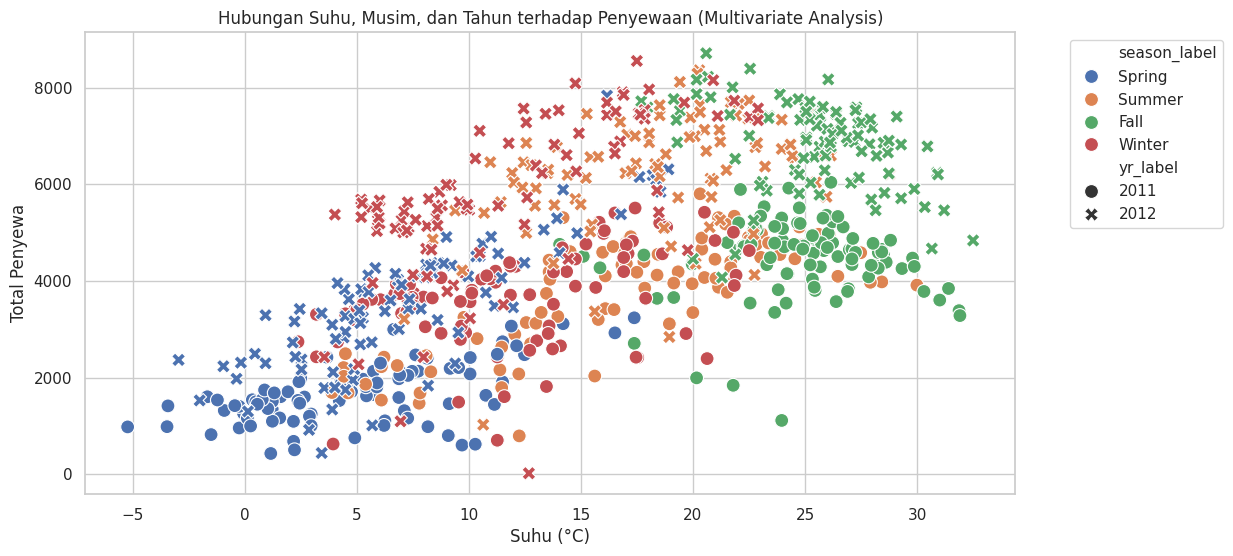

In [110]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=day_df, x='temp_actual', y='cnt', hue='season_label', style='yr_label', palette='deep', s=100)
plt.title('Hubungan Suhu, Musim, dan Tahun terhadap Penyewaan (Multivariate Analysis)')
plt.xlabel('Suhu (°C)')
plt.ylabel('Total Penyewa')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Insight:**
- Insight Pola Cuaca vs Musim: Grafik menunjukkan bahwa suhu optimal untuk bersepeda berada di kisaran 20°C hingga 30°C. Data di area ini didominasi oleh titik-titik musim Fall dan Summer dengan jumlah penyewa tertinggi.
- Insight Anomali: Terlihat bahwa pada suhu yang sama, tahun 2012 (simbol berbeda) secara konsisten memiliki posisi titik yang lebih tinggi dibandingkan 2011.

Kesimpulan Bisnis: Pertumbuhan bisnis dari 2011 ke 2012 tidak hanya dipengaruhi oleh cuaca, tetapi juga oleh faktor lain seperti peningkatan brand awareness atau penambahan jumlah stasiun sepeda, karena pada kondisi suhu yang identik, jumlah penyewa di 2012 tetap lebih banyak.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

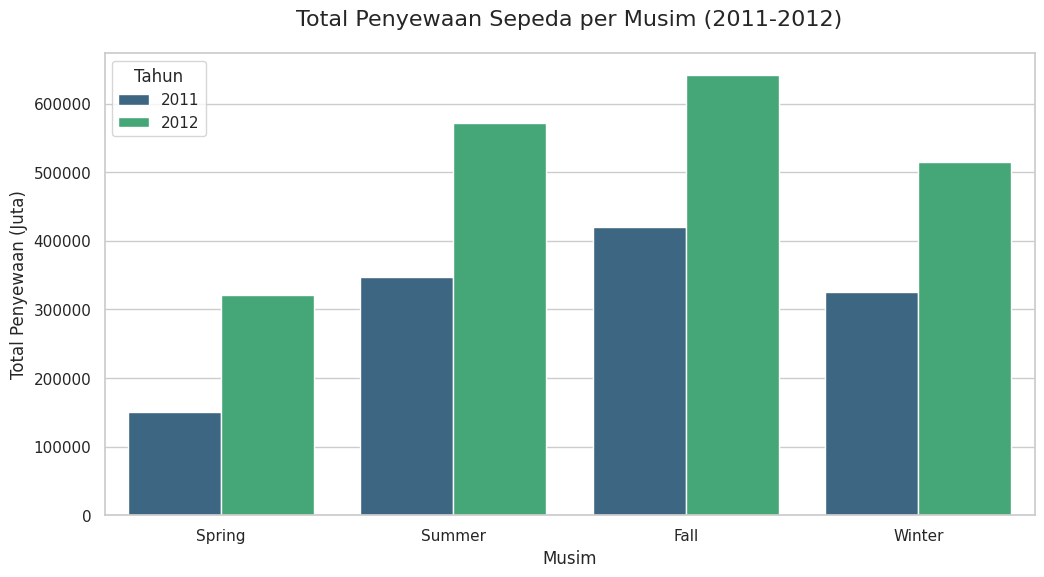

In [111]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.barplot(
    data=day_df,
    x='season_label',
    y='cnt',
    hue='yr_label',
    palette='viridis',
    estimator='sum',
    errorbar=None
)

plt.title('Total Penyewaan Sepeda per Musim (2011-2012)', fontsize=16, pad=20)
plt.xlabel('Musim', fontsize=12)
plt.ylabel('Total Penyewaan (Juta)', fontsize=12)
plt.legend(title='Tahun', loc='upper left')

plt.show()

### Insight Pertanyaan 1: Tren Performa Musiman (2011-2012)
“Bagaimana tren performa penyewaan sepeda pada setiap musim sepanjang tahun 2011-2012 untuk menentukan alokasi armada yang optimal?”

- Dominasi Musim Gugur (Fall): Musim Gugur secara konsisten menjadi periode dengan volume penyewaan tertinggi di kedua tahun. Hal ini menunjukkan bahwa kondisi cuaca pada musim tersebut adalah yang paling ideal bagi pengguna untuk bersepeda.
- Pertumbuhan Signifikan di 2012: Terdapat lonjakan rata-rata penyewaan yang sangat drastis di tahun 2012 pada semua musim dibandingkan tahun 2011. Ini mengindikasikan adanya ekspansi bisnis, penambahan armada, atau peningkatan adopsi pengguna yang berhasil.
- Titik Terendah di Musim Semi (Spring): Musim Semi menunjukkan performa terendah. Ini bisa disebabkan oleh suhu yang masih terlalu dingin di awal tahun atau curah hujan yang tinggi.

### Rekomendasi Strategis Alokasi Armada:

- Prioritas Utama: Perusahaan harus menempatkan jumlah armada maksimal (100% kapasitas) pada musim Fall dan Summer.
- Optimasi Maintenance: Musim Spring adalah waktu terbaik untuk melakukan perawatan besar-besaran (preventive maintenance) pada armada karena beban operasional sedang berada di titik terendah.

### Pertanyaan 2:

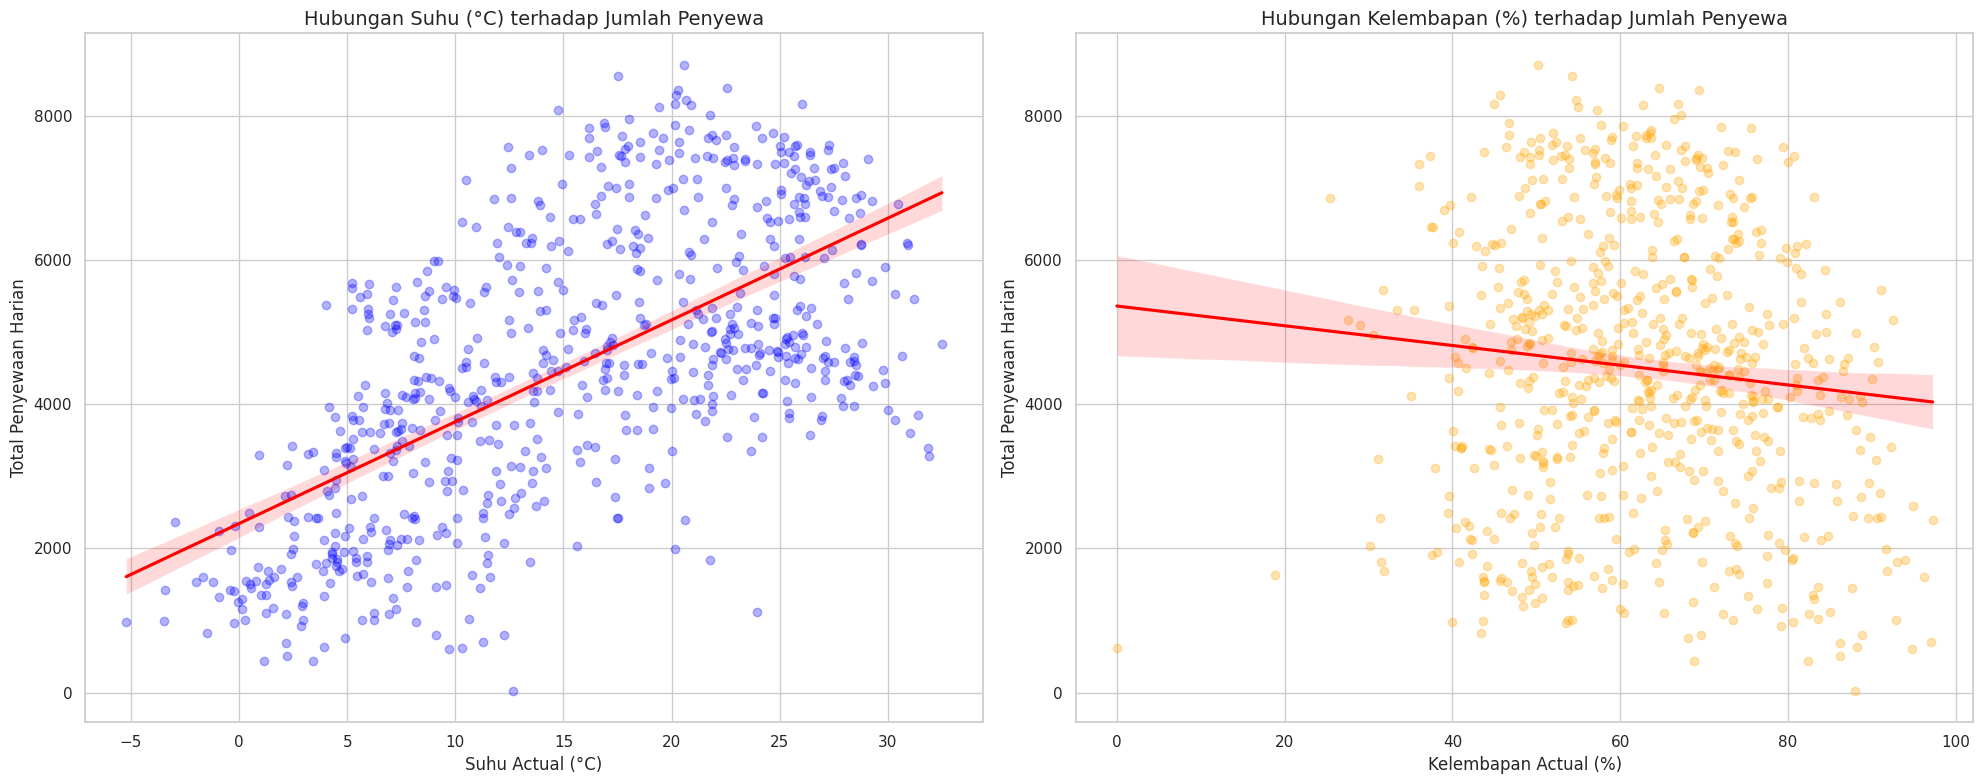

In [112]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

sns.regplot(
    data=day_df,
    x='temp_actual',
    y='cnt',
    scatter_kws={'alpha':0.3, 'color':'blue'},
    line_kws={'color':'red'},
    ax=ax[0]
)
ax[0].set_title('Hubungan Suhu (°C) terhadap Jumlah Penyewa', fontsize=14)
ax[0].set_xlabel('Suhu Actual (°C)')
ax[0].set_ylabel('Total Penyewaan Harian')

sns.regplot(
    data=day_df,
    x='hum_actual',
    y='cnt',
    scatter_kws={'alpha':0.3, 'color':'orange'},
    line_kws={'color':'red'},
    ax=ax[1]
)
ax[1].set_title('Hubungan Kelembapan (%) terhadap Jumlah Penyewa', fontsize=14)
ax[1].set_xlabel('Kelembapan Actual (%)')
ax[1].set_ylabel('Total Penyewaan Harian')

plt.tight_layout()
plt.show()

### Insight Pertanyaan 2: Korelasi Suhu dan Kelembapan
“Bagaimana tingkat korelasi suhu udara dan kelembapan terhadap jumlah total penyewaan sepeda harian selama periode 2011-2012?”

- Suhu adalah Penggerak Utama (Strong Positive Correlation): Grafik Regression Plot menunjukkan garis merah yang menanjak tajam ke kanan atas. Ini membuktikan bahwa semakin hangat suhu udara (hingga titik tertentu), semakin tinggi minat masyarakat untuk menyewa sepeda. Suhu memiliki pengaruh langsung dan kuat terhadap keputusan pengguna.
- Dampak Negatif Kelembapan (Weak Negative Correlation): Sebaliknya, kelembapan memiliki garis yang cenderung mendatar atau sedikit menurun. Hal ini menunjukkan bahwa kelembapan udara yang terlalu tinggi (udara pengap/gerah) sedikit menurunkan jumlah penyewaan, namun pengaruhnya tidak sedominan faktor suhu.
- Zona Nyaman Pengguna: Titik-titik data paling padat (penyewaan tinggi) berkumpul pada rentang suhu 20°C hingga 30°C. Di luar rentang tersebut (terlalu dingin), jumlah penyewaan menurun secara signifikan.

### Rekomendasi Strategis Berbasis Data:

- Prediksi Permintaan: Tim operasional dapat menggunakan ramalan suhu harian sebagai parameter utama untuk memprediksi stok sepeda di setiap stasiun. Jika suhu diprediksi berada di angka 25°C, bersiaplah untuk lonjakan permintaan.
- Mitigasi Cuaca: Karena kelembapan tinggi sedikit menurunkan minat, perusahaan bisa mempertimbangkan promo khusus pada hari-hari dengan kelembapan ekstrem untuk menjaga stabilitas jumlah penyewa.

## Analisis Lanjutan (Opsional)

RFM Analysis per Musim:
   season  frequency  monetary  recency
0    Fall        188   1061129      100
1  Spring        181    471348        0
2  Summer        184    918589      194
3  Winter        178    841613       11


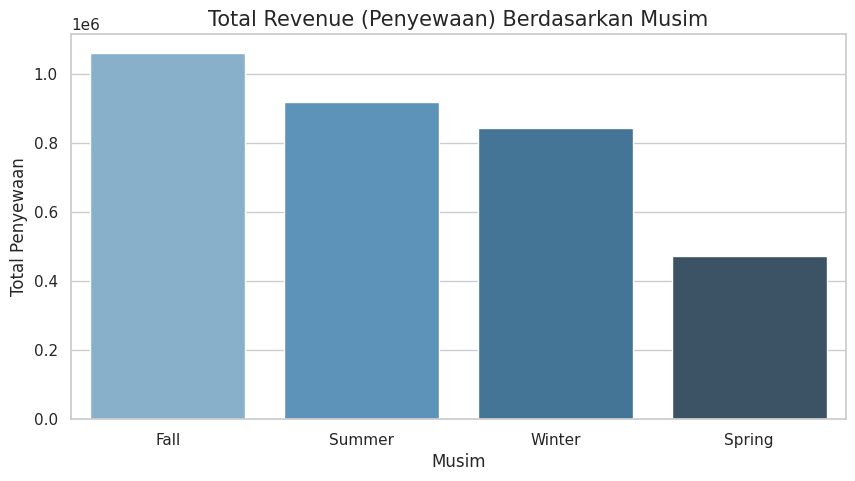

In [113]:
rfm_df = day_df.groupby(by="season_label", as_index=False).agg({
    "dteday": "max",
    "cnt": ["count", "sum"]
})

rfm_df.columns = ["season", "max_recency", "frequency", "monetary"]

recent_date = day_df["dteday"].max()
rfm_df["recency"] = rfm_df["max_recency"].apply(lambda x: (recent_date - x).days)
rfm_df.drop("max_recency", axis=1, inplace=True)

print("RFM Analysis per Musim:")
print(rfm_df)

plt.figure(figsize=(10, 5))

sns.barplot(
    y="monetary",
    x="season",
    data=rfm_df.sort_values(by="monetary", ascending=False),
    palette="Blues_d",
    hue="season",
    legend=False
)

plt.title("Total Revenue (Penyewaan) Berdasarkan Musim", loc="center", fontsize=15)
plt.ylabel("Total Penyewaan")
plt.xlabel("Musim")
plt.show()

## Conclusion & Recommendation

**Pertanyaan 1: Bagaimana tren performa penyewaan sepeda pada setiap musim sepanjang tahun 2011-2012 untuk menentukan alokasi armada yang optimal?**

Berdasarkan analisis tren musiman, penyewaan sepeda mengalami pertumbuhan yang sangat signifikan dari tahun 2011 ke tahun 2012 di seluruh musim.

- Performa Puncak: Musim Fall (Gugur) secara konsisten menjadi musim dengan jumlah penyewaan tertinggi, diikuti oleh musim Summer (Panas). Hal ini menunjukkan bahwa pengguna lebih aktif bersepeda saat kondisi cuaca sedang dalam transisi menuju sejuk atau hangat.
- Performa Terendah: Musim Spring (Semi) menunjukkan angka penyewaan yang paling rendah. Ini menjadi indikator bahwa pada awal tahun, minat atau kondisi operasional mungkin belum mencapai titik optimal.

**Pertanyaan 2: Bagaimana tingkat korelasi suhu udara dan kelembapan terhadap jumlah total penyewaan sepeda harian selama periode 2011-2012?**

Hasil analisis statistik dan visualisasi menunjukkan bahwa variabel cuaca memiliki pengaruh yang berbeda-beda terhadap perilaku pengguna:

- Suhu Udara (Temp): Memiliki korelasi positif yang kuat. Artinya, peningkatan suhu udara (dalam batas nyaman 20°C - 30°C) berbanding lurus dengan peningkatan jumlah penyewa. Suhu adalah faktor pendorong utama (key driver) dalam bisnis ini.
- Kelembapan (Hum): Memiliki korelasi negatif yang lemah. Udara yang terlalu lembap atau pengap cenderung sedikit menurunkan minat orang untuk bersepeda, namun dampaknya tidak sebesar pengaruh suhu udara.

**Rekomendasi Action Item:**

Berdasarkan temuan di atas, berikut adalah rekomendasi aksi untuk manajemen operasional:

1. Strategi Alokasi Armada Berbasis Musim:

   - Maksimalisasi Stok: Siapkan 100% kapasitas armada dan pastikan seluruh stasiun terisi penuh selama musim Fall dan Summer.
   - Jadwal Perawatan (Maintenance): Gunakan periode musim Spring untuk melakukan perawatan besar (overhaul) pada unit sepeda secara bertahap, karena permintaan pasar sedang rendah sehingga risiko kehilangan potensi pendapatan (opportunity cost) lebih kecil.

2. Operasional Adaptif Berbasis Cuaca (Weather-Driven Ops):

   - Gunakan data prakiraan cuaca harian sebagai acuan distribusi armada. Jika suhu diprediksi berada di rentang optimal (22°C - 28°C), tim lapangan harus lebih responsif dalam melakukan rebalancing (pemindahan sepeda dari stasiun penuh ke stasiun kosong).

3. Kampanye Pemasaran Khusus (Seasonal Marketing):

   - Karena musim Spring memiliki performa rendah, buatlah promo "Spring Early Bird" atau program loyalitas khusus di awal tahun untuk menstimulasi minat pengguna agar mulai bersepeda lebih awal sebelum memasuki musim panas.

4. Ekspansi di Tahun Mendatang:

   - Mengingat lonjakan volume yang sangat besar dari 2011 ke 2012, perusahaan disarankan untuk menambah total jumlah armada (investasi aset baru) guna mengantisipasi pertumbuhan permintaan yang diprediksi akan terus meningkat di tahun berikutnya.

In [114]:
# Simpan file untuk dashboard
day_df.to_csv("all_data_clean.csv", index=False)